In [202]:
import torch
import numpy as np

In [203]:
seed = 41
torch.manual_seed(seed=seed)
np.random.seed(seed=seed)

In [204]:
class Model(torch.nn.Module):
    # input layer (4 variables) -> hidden layer 1 (con ciertas neuronas) ->
    # H2 -> output layer (1 unico output de entre tres posibilidades)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    # se eligen h1 y h2 como 8 y 9 respectivamente de forma aleatoria
        super().__init__() # instancia torch.nn.Module
        self.fc1 = torch.nn.Linear(in_features, h1)
        self.fc2 = torch.nn.Linear(h1,h2)
        self.out = torch.nn.Linear(h2, out_features)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.out(x)

        return x


In [205]:
# crear una instancia de la clase Model
model = Model()

In [206]:
import matplotlib.pyplot as plt
import pandas as pd

In [207]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'

my_df = pd.read_csv(url)

In [208]:
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)

In [209]:
# entrenamiento, prueba, validacion
X = my_df.drop('species', axis=1)
y = my_df['species']

# transformar a arrays numpy
X = X.values
y = y.values

In [210]:
from sklearn.model_selection import train_test_split
X_tr, X_test, y_tr, y_test = train_test_split(X, y, train_size=0.8, random_state=41)

In [211]:
# necesitamos convertir los arrays numericos en tensores
X_tr = torch.FloatTensor(X_tr)
X_test = torch.FloatTensor(X_test)

y_tr = y_tr.astype('long')
y_tr = torch.LongTensor(y_tr)

y_test = y_test.astype('long')
y_test = torch.LongTensor(y_test)

In [212]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [213]:
# Ahora entrenamos el modelo
epochs = 2500
losses = []
for epoch in range(epochs):
    # seguir adelante y obtener una prediccion
    y_pred = model.forward(X_tr) # obtener resultados de prediccion

    # medir la perdida, al inicio sera alta
    loss = criterion(y_pred, y_tr) # valores predichos v. y_tr
    # mantemeos record de las perdidas
    losses.append(loss.detach().numpy())

    # imprimir cada 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch: {epoch} and loss: {loss}')
    
    # introducimos el error para que la red neuronal pueda aprender de ello
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch: 0 and loss: 1.1251550912857056
Epoch: 10 and loss: 1.1094491481781006
Epoch: 20 and loss: 1.0956318378448486
Epoch: 30 and loss: 1.0833038091659546
Epoch: 40 and loss: 1.071068525314331
Epoch: 50 and loss: 1.0581412315368652
Epoch: 60 and loss: 1.0439515113830566
Epoch: 70 and loss: 1.027901530265808
Epoch: 80 and loss: 1.006042718887329
Epoch: 90 and loss: 0.9842699766159058
Epoch: 100 and loss: 0.9593889713287354
Epoch: 110 and loss: 0.9310257434844971
Epoch: 120 and loss: 0.898703932762146
Epoch: 130 and loss: 0.8625796437263489
Epoch: 140 and loss: 0.8231237530708313
Epoch: 150 and loss: 0.7819623351097107
Epoch: 160 and loss: 0.7424018979072571
Epoch: 170 and loss: 0.7054346203804016
Epoch: 180 and loss: 0.6709554195404053
Epoch: 190 and loss: 0.6387065052986145
Epoch: 200 and loss: 0.6083163619041443
Epoch: 210 and loss: 0.5795048475265503
Epoch: 220 and loss: 0.5519545674324036
Epoch: 230 and loss: 0.5248971581459045
Epoch: 240 and loss: 0.4977361261844635
Epoch: 250 and 

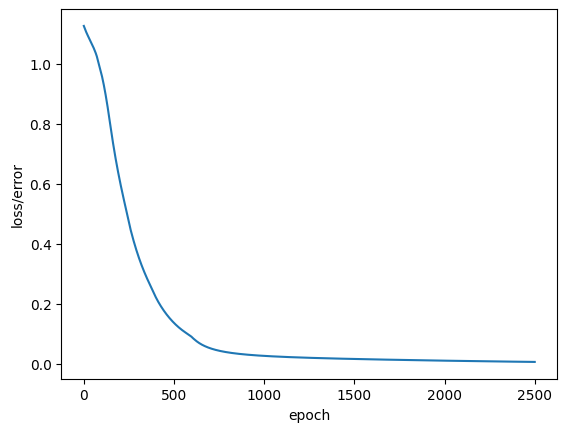

In [214]:
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')
plt.show()

In [215]:
# Evaluar el modelo en el conjunto de entrenamiento
with torch.no_grad():   # sin back propagation
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test) # encuentra una perdida

In [216]:
print(loss)

tensor(0.2738)


In [217]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)
        print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')

        if y_val.argmax().item() == y_test[i]:
            correct += 1

print(f'we got {correct} correct')

1.) tensor([-4.4335,  1.3524,  8.7225]) 	 2
2.) tensor([-5.8549, -1.4097, 14.4042]) 	 2
3.) tensor([-6.9162, -1.0978, 16.1390]) 	 2
4.) tensor([-1.6499,  9.5351, -5.6610]) 	 1
5.) tensor([-5.6291,  0.1347, 12.3384]) 	 2
6.) tensor([ -0.2824,  11.6471, -10.4626]) 	 1
7.) tensor([-4.4604,  2.3604,  7.6601]) 	 2
8.) tensor([-1.4984,  9.5754, -5.9935]) 	 1
9.) tensor([-5.0215,  1.0277, 10.2162]) 	 2
10.) tensor([-6.2758, -1.6455, 15.4747]) 	 2
11.) tensor([-3.9789,  3.3764,  5.5801]) 	 2
12.) tensor([ 20.6730,   9.1777, -42.9209]) 	 0
13.) tensor([ 19.0883,   8.3751, -39.4762]) 	 0
14.) tensor([  1.8392,  10.8718, -13.4050]) 	 1
15.) tensor([ 17.0797,   9.6467, -37.4564]) 	 0
16.) tensor([-3.5731,  5.3917,  2.5224]) 	 2
17.) tensor([ 18.7863,   8.9255, -39.5405]) 	 0
18.) tensor([-4.1545,  2.1403,  7.3101]) 	 1
19.) tensor([ 20.1126,   8.9368, -41.7463]) 	 0
20.) tensor([ 15.7720,   9.0941, -34.7257]) 	 0
21.) tensor([  0.8039,  11.5743, -12.3720]) 	 1
22.) tensor([-6.0949, -0.8475, 14.281